# Content Analysis
Analyzing the versions in `data/dataset`.

In [1]:
import os
import pandas as pd

# DVI2 (cleaned)
dvi2_path = os.path.join("data", "dvi2", "matched")

selected = pd.read_json(
    os.path.join(dvi2_path, "selected_versions.json"), orient='index'
    ).explode("youtube_id").reset_index().rename(
        columns={'index': 'clique_id'}
        )
    
selected_filtered = pd.read_json(
    os.path.join(dvi2_path, "selected_versions_filtered.json"), orient='index'
    ).explode("youtube_id").reset_index().rename(
        columns={'index': 'clique_id'}
        )


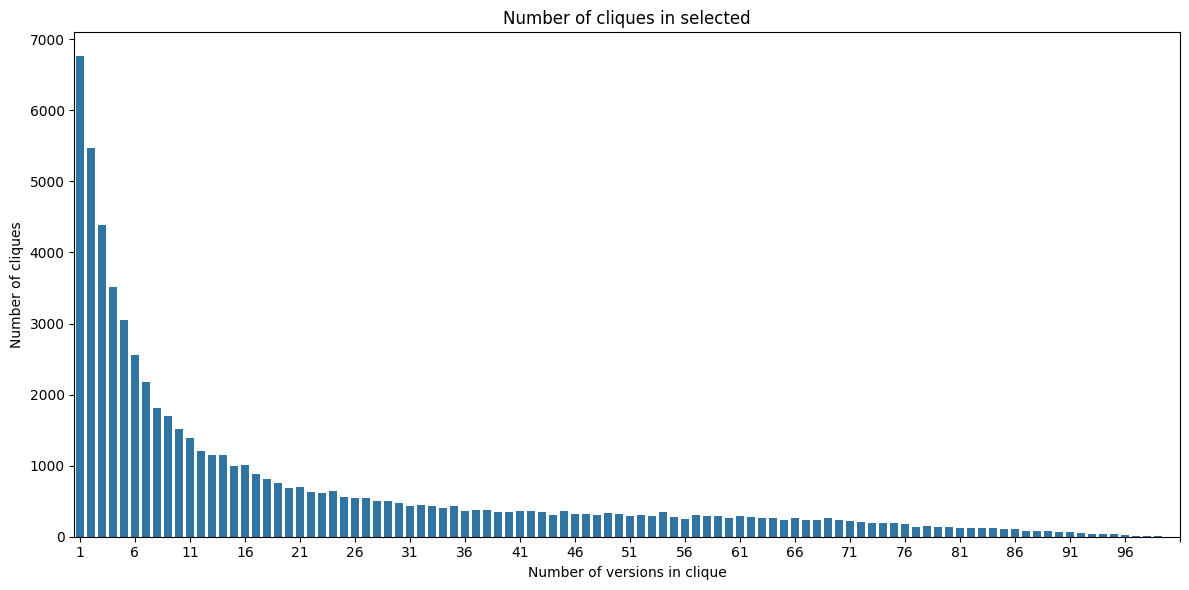

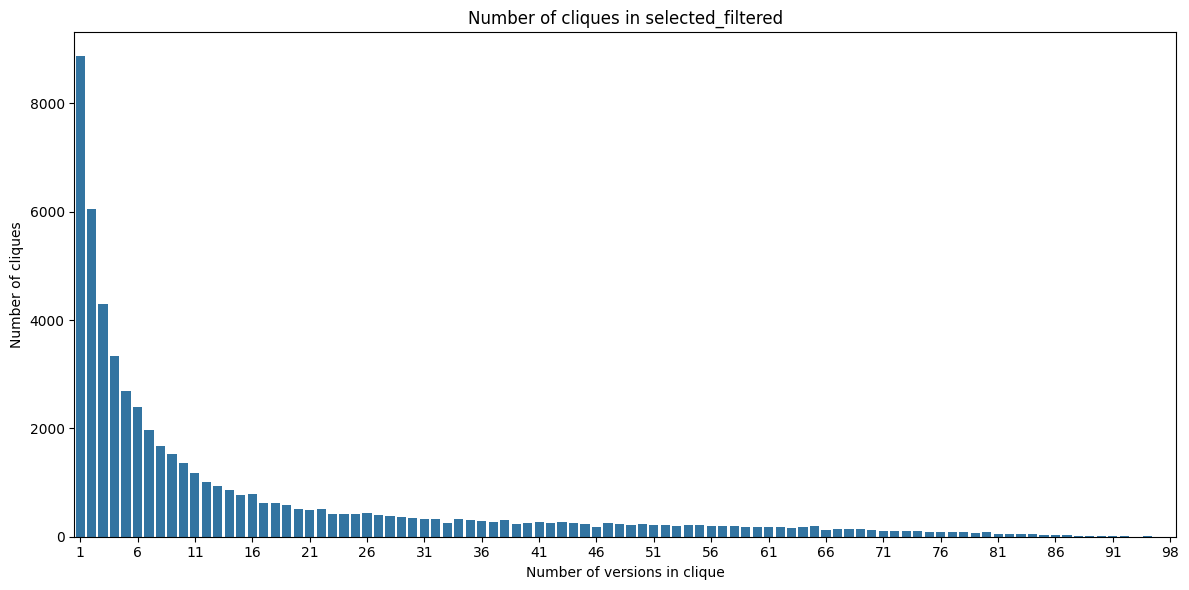

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_clique_size_distribution(selected, dataset_name):
    """
    Plots the distribution of clique sizes from the `selected` dictionary or DataFrame.

    Args:
        selected (dict or DataFrame): Must contain 'clique_id' repeated per YouTube ID.
        title (str): Title of the plot.

    Returns:
        None
    """
    # Compute distribution
    clique_sizes = selected['clique_id'].value_counts()
    size_distribution = clique_sizes.value_counts().sort_index()

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=size_distribution.index, y=size_distribution.values)

    plt.xticks(ticks=range(0, max(size_distribution.index)+1, 5))
    plt.title('Number of cliques in ' + dataset_name)
    plt.xlabel('Number of versions in clique')
    plt.ylabel('Number of cliques')
    plt.tight_layout()
    plt.show()

plot_clique_size_distribution(selected, "selected")
plot_clique_size_distribution(selected_filtered, "selected_filtered")


In [3]:
metadata = pd.read_json("data/metadata_filtered.jsonl", lines=True, orient='records')
metadata = metadata.loc[metadata.id.isin(selected.youtube_id),:]

new_columns = ["clique_id"] + metadata.columns.tolist()
metadata = pd.merge(
    selected.reset_index(),
    metadata,
    left_on="youtube_id",
    right_on="id",
    how="left",
)
metadata = metadata[new_columns]


In [4]:
def time_to_seconds(time_str):
    parts = list(map(int, time_str.split(":")))
    if len(parts) == 3:  # HH:MM:SS
        h, m, s = parts
        return h * 3600 + m * 60 + s
    elif len(parts) == 2:  # MM:SS
        m, s = parts
        return m * 60 + s
    elif len(parts) == 1:  # SS
        return parts[0]
    else:
        raise ValueError(f"Unrecognized time format: {time_str}")
    
metadata["duration_secs"] = metadata["duration"].apply(time_to_seconds)
metadata["duration_mins"] = metadata["duration_secs"] / 60


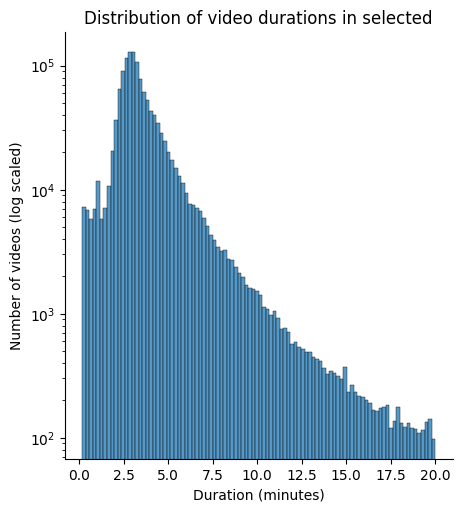

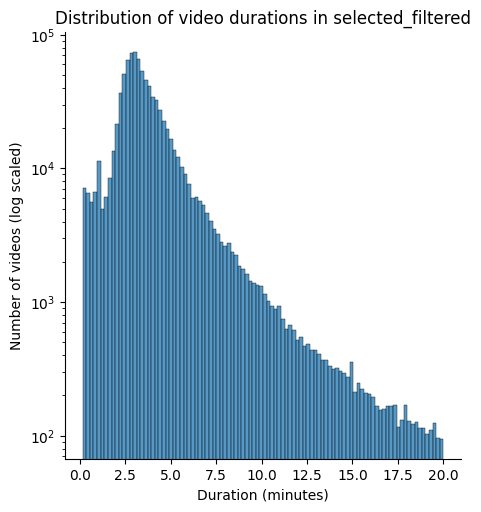

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_duration_distribution(metadata, dataset_name, bins=100):
    sns.displot(metadata, x="duration_mins", bins=bins)
    plt.xlabel("Duration (minutes)")
    plt.ylabel("Number of videos (log scaled)")
    plt.yscale('log')  # <-- set y-axis to log scale
    plt.title('Distribution of video durations in ' + dataset_name)
    plt.show()

plot_duration_distribution(metadata, dataset_name="selected")
plot_duration_distribution(metadata.loc[metadata.id.isin(selected_filtered.youtube_id)], 
                           dataset_name="selected_filtered")


In [6]:
def get_description_str(descriptionSnippet):
    if isinstance(descriptionSnippet, list):
        return " ".join([d["text"] for d in descriptionSnippet]).replace("\n", " ").replace("\r", " ")
    else:
        return descriptionSnippet

metadata["description"] = metadata.descriptionSnippet.apply(get_description_str)


In [7]:
from collections import Counter
from itertools import islice
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Make sure you've downloaded stopwords & tokenizer models:
# import nltk
# nltk.download('punkt')
# nltk.download('stopwords')

# Combine stopwords from multiple languages
languages = ['english', 'german', 'french', 'spanish', 'italian', 'portuguese']  # extend as needed
stop_words = set()
for lang in languages:
    stop_words.update(stopwords.words(lang))

def ngrams(tokens, n):
    return zip(*(islice(tokens, i, None) for i in range(n)))

def clean_and_tokenize(text):
    tokens = word_tokenize(text.lower())
    return [word for word in tokens if word.isalnum() and word not in stop_words]

def get_top_ngrams(series, n=1, top_k=20):
    all_ngrams = Counter()
    for text in series.dropna().astype(str):
        tokens = clean_and_tokenize(text)
        all_ngrams.update(ngrams(tokens, n))
    return all_ngrams.most_common(top_k)

# Assuming your dataframe is called df
for column in ['title', 'description']:
    print(f"\n==== {column.upper()} ====")
    for n in [1, 2, 3]:
        top = get_top_ngrams(metadata[column], n=n, top_k=15)  # adjust top_k as needed
        print(f"\nTop {n}-grams (stopwords removed):")
        for phrase, count in top:
            joined = " ".join(phrase) if isinstance(phrase, tuple) else phrase
            print(f"{joined}: {count}")



==== TITLE ====

Top 1-grams (stopwords removed):
cover: 63510
live: 61103
love: 48687
blues: 42778
remastered: 29239
version: 25604
lyrics: 23419
karaoke: 21011
little: 17606
guitar: 17431
time: 15636
baby: 15381
video: 14918
heart: 14046
john: 12856

Top 2-grams (stopwords removed):
karaoke version: 8162
bob dylan: 4391
official audio: 4146
elvis presley: 4119
taylor swift: 3930
first time: 3865
guitar cover: 3708
music video: 3411
guitar lesson: 3266
remastered 2014: 3151
bass cover: 2960
official video: 2666
time hearing: 2492
acoustic cover: 2485
drum cover: 2310

Top 3-grams (stopwords removed):
first time hearing: 2468
official music video: 1834
karaoke version karafun: 1068
karaoke version zoom: 952
version zoom karaoke: 941
nat king cole: 923
bob dylan cover: 860
townes van zandt: 818
version originally performed: 783
karaoke version originally: 776
first time reaction: 743
jerry lee lewis: 710
guitar lesson tutorial: 608
creedence clearwater revival: 587
karaoke version styl

In [8]:
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from itertools import islice

# Ensure required NLTK resources are downloaded
nltk.download('punkt')
nltk.download('stopwords')

def analyze_top_ngrams(
    df,
    ngram_range=(1, 3),
    top_k=15,
    languages=('english', 'german', 'french', 'spanish', 'italian', 'portuguese')
):
    """
    Analyzes top n-grams in specified text columns of a DataFrame after cleaning and stopword removal.

    Args:
        df (pd.DataFrame): DataFrame containing text data.
        ngram_range (tuple): (min_n, max_n) tuple for n-gram lengths.
        top_k (int): Number of top n-grams to return.
        languages (tuple): Languages whose stopwords to combine.

    Returns:
        dict: Nested dictionary of top n-grams per column and n.
    """
    # Compile stopwords from multiple languages
    stop_words = set()
    for lang in languages:
        stop_words.update(stopwords.words(lang))

    def ngrams(tokens, n):
        return zip(*(islice(tokens, i, None) for i in range(n)))

    def clean_and_tokenize(text):
        tokens = word_tokenize(text.lower())
        return [word for word in tokens if word.isalnum() and word not in stop_words]

    results = {}

    text_columns = ['title', 'description']
    for column in text_columns:
        print(f"\n==== {column.upper()} ====")
        col_results = {}
        for n in range(ngram_range[0], ngram_range[1] + 1):
            all_ngrams = Counter()
            for text in df[column].dropna().astype(str):
                tokens = clean_and_tokenize(text)
                all_ngrams.update(ngrams(tokens, n))
            top = all_ngrams.most_common(top_k)

            print(f"\nTop {n}-grams (stopwords removed):")
            for phrase, count in top:
                joined = " ".join(phrase) if isinstance(phrase, tuple) else phrase
                print(f"{joined}: {count}")

            col_results[n] = top
        results[column] = col_results

    return results

results_metadata = analyze_top_ngrams(
    metadata,
    ngram_range=(1, 3),
    top_k=15
)



[nltk_data] Downloading package punkt to /home/azimuth/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/azimuth/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



==== TITLE ====

Top 1-grams (stopwords removed):
cover: 63510
live: 61103
love: 48687
blues: 42778
remastered: 29239
version: 25604
lyrics: 23419
karaoke: 21011
little: 17606
guitar: 17431
time: 15636
baby: 15381
video: 14918
heart: 14046
john: 12856

Top 2-grams (stopwords removed):
karaoke version: 8162
bob dylan: 4391
official audio: 4146
elvis presley: 4119
taylor swift: 3930
first time: 3865
guitar cover: 3708
music video: 3411
guitar lesson: 3266
remastered 2014: 3151
bass cover: 2960
official video: 2666
time hearing: 2492
acoustic cover: 2485
drum cover: 2310

Top 3-grams (stopwords removed):
first time hearing: 2468
official music video: 1834
karaoke version karafun: 1068
karaoke version zoom: 952
version zoom karaoke: 941
nat king cole: 923
bob dylan cover: 860
townes van zandt: 818
version originally performed: 783
karaoke version originally: 776
first time reaction: 743
jerry lee lewis: 710
guitar lesson tutorial: 608
creedence clearwater revival: 587
karaoke version styl

In [9]:
results_metadata = analyze_top_ngrams(
    metadata.loc[metadata.id.isin(selected_filtered.youtube_id)],
    ngram_range=(1, 3),
    top_k=15
)



==== TITLE ====

Top 1-grams (stopwords removed):
cover: 62782
live: 54030
love: 34936
lyrics: 23128
blues: 20899
version: 17899
guitar: 16789
karaoke: 15851
time: 12579
john: 11889
little: 11259
band: 10177
heart: 9968
baby: 9611
song: 9557

Top 2-grams (stopwords removed):
karaoke version: 4321
bob dylan: 4137
first time: 3728
guitar cover: 3706
elvis presley: 3680
taylor swift: 3508
guitar lesson: 3264
bass cover: 2959
acoustic cover: 2475
time hearing: 2435
drum cover: 2306
hits archive: 2106
johnny cash: 1949
stevie wonder: 1903
frank sinatra: 1766

Top 3-grams (stopwords removed):
first time hearing: 2411
karaoke version karafun: 1068
karaoke version zoom: 952
version zoom karaoke: 941
nat king cole: 890
bob dylan cover: 853
townes van zandt: 724
first time reaction: 721
jerry lee lewis: 691
guitar lesson tutorial: 608
creedence clearwater revival: 528
bass cover tabs: 455
stevie ray vaughan: 403
gladys knight pips: 400
tom petty heartbreakers: 356

==== DESCRIPTION ====

Top 1-